# Store Item Demand Forecasting

## Business Problem

Retail companies need accurate demand forecasts to optimize inventory management and reduce operational costs.

The objective of this project is to predict future daily sales for each item in each store using historical sales data.

### Business Goals

- Reduce stock shortages
- Minimize overstock costs
- Improve inventory planning
- Improve supply chain efficiency

### Machine Learning Task

- Supervised Learning
- Regression
- Time Series Forecasting

### Target Variable

sales

## Dataset Overview

The dataset contains historical daily sales records for multiple stores and items.

### Available Features

| Feature | Description |
|----------|-------------|
| date | Date of the sale |
| store | Store identifier |
| item | Item identifier |
| sales | Number of items sold (Target) |

### Dataset Characteristics

- Daily observations
- Multiple stores
- Multiple products
- Time-dependent target
- Suitable for time-series forecasting

## Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb

from sklearn.metrics import mean_absolute_error

import joblib

from datetime import datetime

plt.style.use("default")

print("Libraries Loaded Successfully ✅")

Libraries Loaded Successfully ✅


## Data Loading and Initial Inspection

In [2]:
train = pd.read_csv('../Data/train.csv', parse_dates=['date'])
test  = pd.read_csv('../Data/test.csv', parse_dates=['date'])

train['is_test'] = 0
test['is_test']  = 1
test['sales']    = np.nan

df = pd.concat([train, test], sort=False)
df = df.sort_values(['store','item','date']).reset_index(drop=True)

In [3]:
print("Train Shape:", train.shape)
print("Test Shape :", test.shape)

print("\nTrain Columns:")
print(train.columns.tolist())

Train Shape: (913000, 5)
Test Shape : (45000, 6)

Train Columns:
['date', 'store', 'item', 'sales', 'is_test']


In [4]:
train.head()

,date,store,item,sales,is_test
0,2013-01-01,1,1,13,0
1,2013-01-02,1,1,11,0
2,2013-01-03,1,1,14,0
3,2013-01-04,1,1,13,0
4,2013-01-05,1,1,10,0


### Initial Data Observations

- The training dataset contains 913,000 records.
- The test dataset contains 45,000 records.
- The dataset consists of daily sales observations.
- Each record represents the sales of a specific item in a specific store on a specific date.
- The target variable is `sales`.
- The `date` column has been successfully parsed as datetime.
- `store` and `item` act as identifiers and will be used for feature engineering.

## Data Structure Audit

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   date     913000 non-null  datetime64[ns]
 1   store    913000 non-null  int64         
 2   item     913000 non-null  int64         
 3   sales    913000 non-null  int64         
 4   is_test  913000 non-null  int64         
dtypes: datetime64[ns](1), int64(4)
memory usage: 34.8 MB


### Data Structure Analysis

#### Findings

- The dataset contains 913,000 observations.
- No missing values are detected at the structural level.
- The `date` column is correctly stored as `datetime64`.
- The remaining variables are stored as integer values.
- Memory consumption is relatively low (~34.8 MB).
- No immediate datatype corrections are required.

#### Initial Interpretation

- `sales` is the numerical target variable.
- `store` and `item` are identifiers rather than continuous numerical variables.
- The `date` column will be the primary source for time-based feature engineering.

## Missing Values Assessment

In [6]:
missing_values = train.isnull().sum()

missing_report = pd.DataFrame({
    "Missing Values": missing_values,
    "Missing Percentage": round(
        missing_values / len(train) * 100,
        4
    )
})

missing_report

,Missing Values,Missing Percentage
date,0,0.0
store,0,0.0
item,0,0.0
sales,0,0.0
is_test,0,0.0


### Missing Values Analysis

#### Findings

- No missing values were detected in any feature.
- Data completeness is 100%.
- No imputation techniques are required.

#### Impact on Modeling

The absence of missing values reduces preprocessing complexity and eliminates the need for missing-value handling strategies.

## Duplicate Records Assessment

In [7]:
duplicate_count = train.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


### Duplicate Records Analysis

#### Findings

- No duplicate records were detected.
- Each observation represents a unique store-item-date combination.

#### Impact on Modeling

The absence of duplicate observations ensures that model training will not be biased by repeated records.

## Cardinality Analysis

In [8]:
cardinality = pd.DataFrame({
    "Unique Values": train.nunique()
})

cardinality

,Unique Values
date,1826
store,10
item,50
sales,213
is_test,1


### Cardinality Analysis

#### Findings

- The dataset covers 1,826 unique dates.
- There are 10 unique stores.
- There are 50 unique items.
- The target variable (`sales`) contains 213 unique values.

#### Business Interpretation

- Sales are observed daily over approximately 5 years.
- Forecasting must capture both long-term trends and seasonality.
- The problem consists of 500 unique Store-Item combinations (10 × 50).
- Demand patterns may vary significantly across stores and products.

## Target Variable Analysis

In [9]:
train["sales"].describe()

count    913000.000000
mean         52.250287
std          28.801144
min           0.000000
25%          30.000000
50%          47.000000
75%          70.000000
max         231.000000
Name: sales, dtype: float64

In [10]:
print("Skewness :", train["sales"].skew())
print("Kurtosis :", train["sales"].kurt())

Skewness : 0.8671122960235801
Kurtosis : 0.5090704757198123


### Target Distribution Analysis

#### Statistical Summary

- Average daily sales: 52.25 units
- Median daily sales: 47 units
- Minimum sales: 0 units
- Maximum sales: 231 units

#### Distribution Characteristics

- The target variable shows a positive skewness (0.87).
- The distribution is moderately right-skewed.
- A small number of observations have significantly higher sales than the majority.
- Kurtosis is relatively low (0.51), indicating the absence of extreme heavy tails.

#### Modeling Implications

- The target distribution is not perfectly normal.
- Applying a logarithmic transformation may help stabilize variance.
- This supports the use of a Log-Transformed LightGBM model.

## Sales Distribution

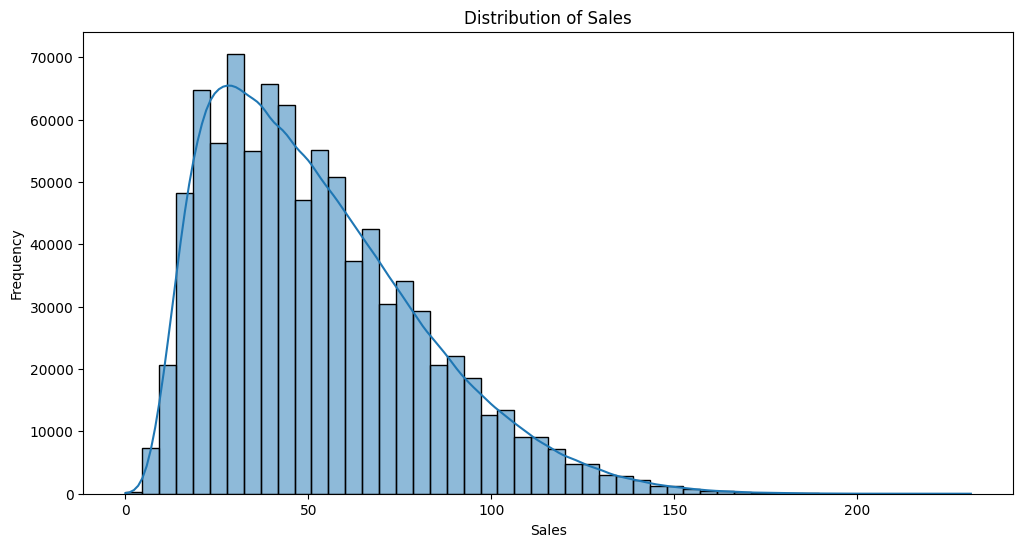

In [11]:
plt.figure(figsize=(12,6))

sns.histplot(
    train["sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

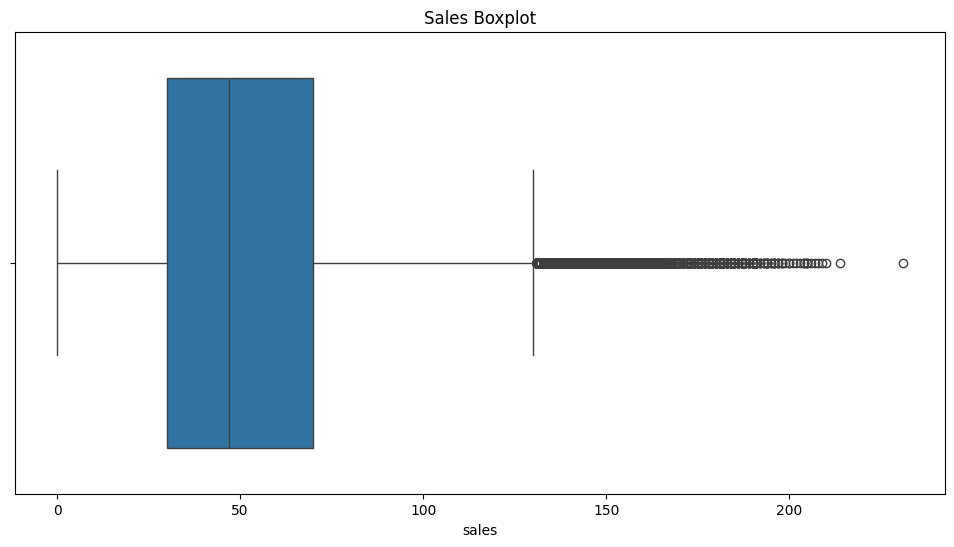

In [12]:
plt.figure(figsize=(12,6))

sns.boxplot(
    x=train["sales"]
)

plt.title("Sales Boxplot")
plt.show()

### Visual Analysis of Sales Distribution

#### Histogram Findings

- The sales distribution is positively skewed.
- Most observations are concentrated between 20 and 80 units.
- A long right tail is visible, indicating the presence of high-sales observations.
- The target variable does not follow a normal distribution.

#### Boxplot Findings

- A considerable number of upper-end outliers are present.
- High sales values appear naturally in the dataset.
- These observations likely represent genuine demand spikes rather than data errors.

#### Modeling Decision

- Outliers will not be removed because they may contain important business information.
- Tree-based models such as LightGBM are generally robust to outliers.
- A logarithmic transformation can help stabilize the target distribution.

## Time Series Analysis

In [13]:
daily_sales = train.groupby("date")["sales"].sum()

daily_sales.head()

date
2013-01-01    13696
2013-01-02    13678
2013-01-03    14488
2013-01-04    15677
2013-01-05    16237
Name: sales, dtype: int64

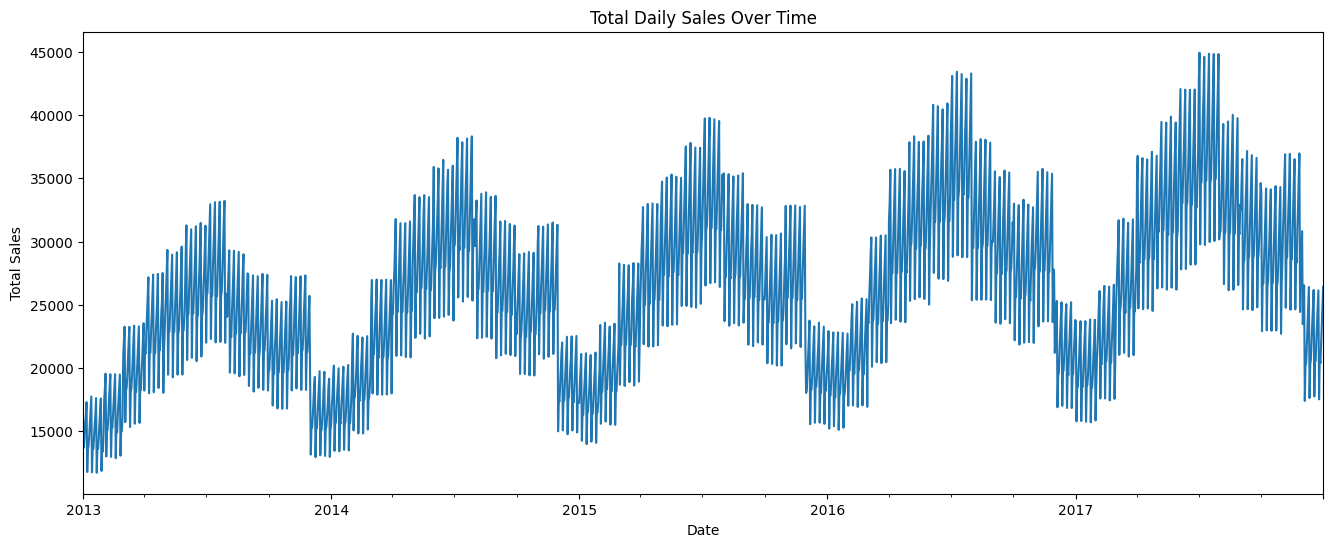

In [14]:
plt.figure(figsize=(16,6))

daily_sales.plot()

plt.title("Total Daily Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.show()

### Time Series Analysis

#### Trend Analysis

- Total sales show a clear upward trend over time.
- Demand gradually increases from 2013 to 2017.
- The business appears to be growing over the observed period.

#### Seasonality Analysis

- Strong recurring patterns are visible throughout the timeline.
- Similar sales movements repeat every year.
- This indicates the presence of annual seasonality.

#### Weekly Pattern

- Frequent repetitive spikes are observed.
- These spikes suggest a strong day-of-week effect.
- Customer purchasing behavior changes across weekdays and weekends.

#### Modeling Implications

The forecasting model should capture:

- Long-term trend
- Weekly seasonality
- Annual seasonality
- Short-term demand fluctuations

This justifies the creation of:

- Lag Features
- Rolling Statistics
- Exponentially Weighted Features
- Cyclic Calendar Features

## Monthly Seasonality Analysis

In [15]:
monthly_sales = (
    train.groupby(
        train["date"].dt.month
    )["sales"]
    .mean()
)

monthly_sales

date
1     35.524503
2     39.378397
3     47.305574
4     55.152893
5     59.128219
6     63.025480
7     66.998619
8     59.105226
9     55.072760
10    51.193806
11    55.218080
12    39.365265
Name: sales, dtype: float64

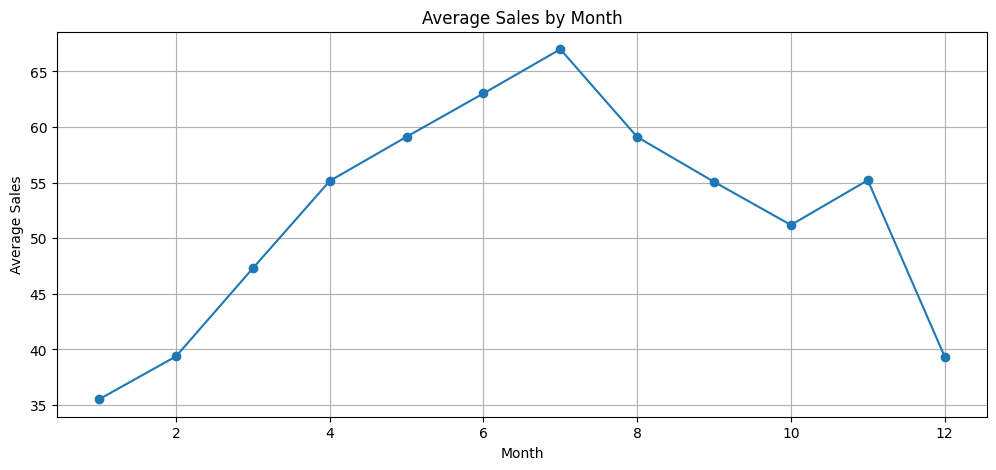

In [16]:
plt.figure(figsize=(12,5))

monthly_sales.plot(
    marker="o"
)

plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True)
plt.show()

### Monthly Seasonality Analysis

#### Findings

- Sales increase steadily from January to July.
- July records the highest average demand (~67 units).
- Demand starts declining after July.
- December experiences one of the lowest sales levels.
- Strong seasonal behavior is present across months.

#### Business Interpretation

- Customer demand changes significantly throughout the year.
- Certain months consistently generate higher sales volumes.
- Inventory requirements are expected to vary seasonally.

#### Modeling Implications

The model must capture monthly seasonality.

This justifies the use of:

- month
- quarter
- month_sin
- month_cos

features during feature engineering.

## Day of Week Analysis

In [17]:
weekday_sales = (
    train.groupby(
        train["date"].dt.day_name()
    )["sales"]
    .mean()
)

weekday_sales

date
Friday       55.157249
Monday       41.429638
Saturday     58.662697
Sunday       62.143333
Thursday     51.723218
Tuesday      48.225908
Wednesday    48.368506
Name: sales, dtype: float64

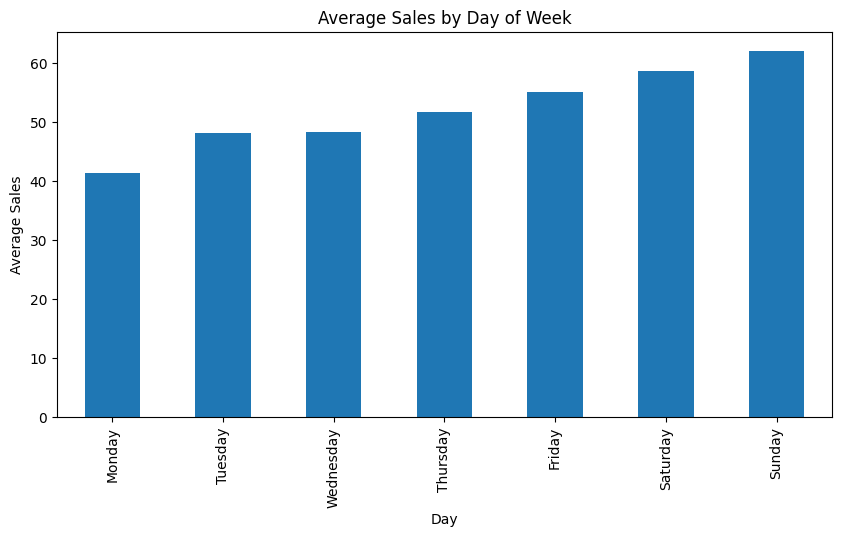

In [18]:
weekday_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

weekday_sales = weekday_sales.reindex(
    weekday_order
)

plt.figure(figsize=(10,5))

weekday_sales.plot(
    kind="bar"
)

plt.title("Average Sales by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Sales")

plt.show()

### Weekly Seasonality Analysis

#### Findings

- Sales vary significantly across days of the week.
- Monday records the lowest average sales (~41 units).
- Demand gradually increases throughout the week.
- Weekend sales are substantially higher than weekday sales.
- Sunday has the highest average sales (~62 units).

#### Business Interpretation

- Customer purchasing behavior strongly depends on the day of the week.
- Weekends drive the highest demand levels.
- Inventory planning should account for increased weekend demand.

#### Modeling Implications

Strong weekly seasonality exists in the dataset.

This justifies the creation of:

- day_of_week
- is_weekend
- dow_sin
- dow_cos

features.

## Store-Level Analysis

In [19]:
store_sales = (
    train.groupby("store")["sales"]
    .mean()
    .sort_values()
)

store_sales

store
7     36.363735
6     39.733516
5     39.770164
1     47.268379
4     54.902946
9     55.049025
10    58.709288
3     59.530602
8     64.142048
2     67.033165
Name: sales, dtype: float64

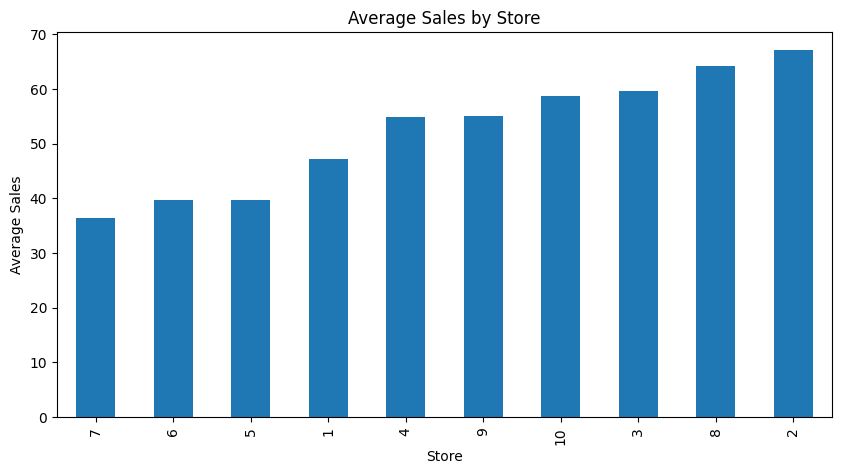

In [20]:
plt.figure(figsize=(10,5))

store_sales.plot(
    kind="bar"
)

plt.title("Average Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Sales")

plt.show()

### Store-Level Analysis

#### Findings

- Significant differences exist between stores.
- Store 2 records the highest average sales (~67 units).
- Store 7 records the lowest average sales (~36 units).
- The gap between the best and worst performing stores is substantial.

#### Business Interpretation

- Store performance is not uniform.
- Customer demand varies considerably across locations.
- Each store exhibits its own demand profile.

#### Modeling Implications

Store information contains strong predictive power.

This supports the inclusion of:

- store
- store_mean
- store_item_mean
- store_item_std

features in the forecasting model.

## Item-Level Analysis

In [21]:
item_sales = (
    train.groupby("item")["sales"]
    .mean()
    .sort_values()
)

item_sales.head(10)

item
5     18.358708
1     21.981599
41    22.002136
47    22.003341
4     22.010241
27    22.049726
16    25.656079
34    25.735761
40    29.249398
37    29.258379
Name: sales, dtype: float64

In [22]:
item_sales.tail(10)

item
8     76.950055
36    77.028916
22    80.502245
38    80.521906
45    80.584173
25    80.686418
18    84.275794
13    84.316594
28    87.881325
15    88.030778
Name: sales, dtype: float64

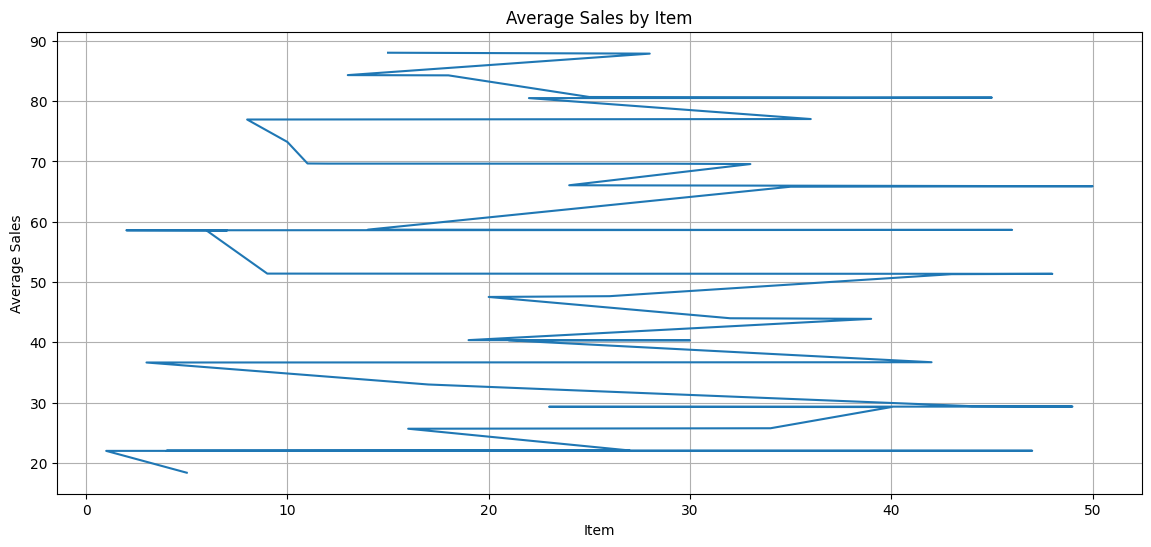

In [23]:
plt.figure(figsize=(14,6))

item_sales.plot()

plt.title("Average Sales by Item")
plt.xlabel("Item")
plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

### Item-Level Analysis

#### Findings

- Significant differences exist between products.
- The lowest-demand items generate approximately 18–30 sales per day.
- The highest-demand items generate approximately 77–88 sales per day.
- Demand varies considerably across products.

#### Business Interpretation

- Some products are consistently more popular than others.
- Product-specific demand patterns are clearly present.
- Different inventory strategies may be required for different products.

#### Modeling Implications

Product information contains strong predictive power.

This supports the inclusion of:

- item
- item_mean
- store_item_mean
- store_item_std

features in the forecasting model.

# Exploratory Data Analysis Summary

## Key Findings

### Data Quality

- No missing values detected.
- No duplicate records detected.
- Data types are correctly formatted.

### Target Variable

- Sales distribution is positively skewed.
- High-sales observations are naturally present.
- Log transformation is expected to improve modeling.

### Time Series Characteristics

- Strong upward trend exists.
- Annual seasonality is present.
- Weekly seasonality is very strong.

### Store Effects

- Significant variation exists across stores.

### Item Effects

- Significant variation exists across products.

## Feature Engineering Strategy

Based on the analysis above, the forecasting model should capture:

- Trend
- Seasonality
- Weekly effects
- Store effects
- Item effects
- Historical demand behavior

# Feature Engineering

Feature engineering is the most important component of this forecasting system.

The objective is to transform raw historical data into predictive signals that capture:

- Calendar effects
- Seasonality
- Historical demand
- Long-term trends
- Store-item behavior

The following feature groups will be created:

1. Calendar Features
2. Cyclic Features
3. Lag Features
4. Rolling Statistics
5. Exponentially Weighted Features
6. Trend Features
7. Store-Item Aggregations

## Calendar Features

Calendar features help the model understand temporal patterns in demand.

These features capture:

- Monthly seasonality
- Quarterly effects
- Position within the year
- Position within the month
- Weekly patterns

Feature List:

- month
- day
- day_of_week
- day_of_year
- week_of_year
- quarter
- is_weekend
- is_month_start
- is_month_end

### Why Calendar Features?

Demand is highly influenced by time.

For example:

- July showed the highest average sales.
- Weekend sales were significantly higher than weekdays.
- Strong yearly and weekly seasonality was observed during EDA.

Calendar features allow the model to learn these recurring patterns.

In [24]:
df['month']        = df.date.dt.month
df['day']          = df.date.dt.day
df['day_of_week']  = df.date.dt.dayofweek
df['day_of_year']  = df.date.dt.dayofyear
df['week_of_year'] = df.date.dt.isocalendar().week.astype(int)
df['quarter']      = df.date.dt.quarter
df['is_weekend']   = (df.day_of_week >= 5).astype(int)
df['is_month_start'] = df.date.dt.is_month_start.astype(int)
df['is_month_end']   = df.date.dt.is_month_end.astype(int)

In [25]:
calendar_features = [
    'month',
    'day',
    'day_of_week',
    'day_of_year',
    'week_of_year',
    'quarter',
    'is_weekend',
    'is_month_start',
    'is_month_end'
]

df[calendar_features].head()

,month,day,day_of_week,day_of_year,week_of_year,quarter,is_weekend,is_month_start,is_month_end
0,1,1,1,1,1,1,0,1,0
1,1,2,2,2,1,1,0,0,0
2,1,3,3,3,1,1,0,0,0
3,1,4,4,4,1,1,0,0,0
4,1,5,5,5,1,1,1,0,0


## Cyclic Features

In [26]:
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype(np.float32)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype(np.float32)
df['dow_sin']   = np.sin(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)
df['dow_cos']   = np.cos(2 * np.pi * df['day_of_week'] / 7).astype(np.float32)

In [27]:
cyclic_cols = [
    'month',
    'month_sin',
    'month_cos',
    'day_of_week',
    'dow_sin',
    'dow_cos'
]

df[cyclic_cols].head(10)

,month,month_sin,month_cos,day_of_week,dow_sin,dow_cos
0,1,0.5,0.866025,1,0.781832,0.623490
1,1,0.5,0.866025,2,0.974928,-0.222521
2,1,0.5,0.866025,3,0.433884,-0.900969
3,1,0.5,0.866025,4,-0.433884,-0.900969
4,1,0.5,0.866025,5,-0.974928,-0.222521
5,1,0.5,0.866025,6,-0.781832,0.623490
6,1,0.5,0.866025,0,0.000000,1.000000
7,1,0.5,0.866025,1,0.781832,0.623490
8,1,0.5,0.866025,2,0.974928,-0.222521
9,1,0.5,0.866025,3,0.433884,-0.900969


### Cyclic Features Summary

Cyclic encoding was applied to preserve the natural circular relationship between:

- Months of the year
- Days of the week

This helps the model learn seasonal patterns more effectively than raw integer encoding.

## Lag Features

In [28]:
LAGS = [91, 98, 105, 112, 119, 126, 182, 364, 546, 728]

In [29]:
for lag in LAGS:
    df[f'lag_{lag}'] = df.groupby(['store','item'])['sales'].shift(lag)

In [30]:
lag_cols = [
    c for c in df.columns
    if c.startswith("lag_")
]

df[
    lag_cols[:5]
].head(120)

,lag_91,lag_98,lag_105,lag_112,lag_119
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
115,14.0,7.0,9.0,13.0,NaN
116,12.0,18.0,7.0,10.0,NaN
117,12.0,15.0,10.0,12.0,NaN
118,11.0,8.0,12.0,10.0,NaN


In [31]:
df[lag_cols].isnull().mean().head()

lag_91     0.047495
lag_98     0.051148
lag_105    0.054802
lag_112    0.058455
lag_119    0.062109
dtype: float64

### Lag Features Summary

Lag features capture historical demand observations.

Examples:

- lag_91  → sales 91 days ago
- lag_364 → sales 1 year ago
- lag_728 → sales 2 years ago

Observations:

- Missing values at the beginning of each series are expected.
- No data leakage is introduced.
- Historical demand is one of the strongest predictors in forecasting problems.

## Rolling Statistics Features

In [32]:
df['_shifted'] = (
    df.groupby(
        ['store','item']
    )['sales']
    .shift(91)
)

In [33]:
ROLL_WINDOWS = [
    30,
    60,
    90,
    180,
    365,
    546
]

In [34]:
for w in ROLL_WINDOWS:

    _g = df.groupby(
        ['store','item']
    )['_shifted']

    df[f'roll_mean_{w}'] = (
        _g.transform(
            lambda x:
            x.rolling(
                w,
                min_periods=5
            ).mean()
        )
    )

    df[f'roll_std_{w}'] = (
        _g.transform(
            lambda x:
            x.rolling(
                w,
                min_periods=5
            ).std()
        )
    )

In [35]:
df.drop(
    "_shifted",
    axis=1,
    inplace=True
)

In [36]:
roll_cols = [
    c for c in df.columns
    if c.startswith("roll_")
]

len(roll_cols)

12

In [37]:
roll_cols[:6]

['roll_mean_30',
 'roll_std_30',
 'roll_mean_60',
 'roll_std_60',
 'roll_mean_90',
 'roll_std_90']

In [38]:
df[
    [
        'roll_mean_30',
        'roll_std_30',
        'roll_mean_90',
        'roll_std_90'
    ]
].head(120)

,roll_mean_30,roll_std_30,roll_mean_90,roll_std_90
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN
...,...,...,...,...
115,10.600000,3.240370,10.600000,3.240370
116,10.653846,3.186751,10.653846,3.186751
117,10.703704,3.135587,10.703704,3.135587
118,10.714286,3.077483,10.714286,3.077483


### Rolling Features Summary

Rolling statistics capture demand behavior over different historical windows.

Features created:

- Rolling means
- Rolling standard deviations

These features provide information about:

- Average historical demand
- Demand volatility
- Long-term demand behavior

The use of shift(91) prevents data leakage by ensuring that only past information is used.

## Exponentially Weighted Features

In [39]:
ALPHAS = [
    0.95,
    0.90,
    0.80,
    0.70,
    0.50
]

LAGS_EWM = [
    91,
    182,
    364
]

In [40]:
for alpha in ALPHAS:

    for lag in LAGS_EWM:

        col = (
            f'ewm_'
            f'{str(alpha).replace(".","_")}'
            f'_{lag}'
        )

        df[col] = (

            df.groupby(
                ['store','item']
            )['sales']

            .shift(lag)

            .transform(
                lambda x:
                x.ewm(
                    alpha=alpha,
                    adjust=False
                ).mean()
            )
        )

In [41]:
ewm_cols = [
    c for c in df.columns
    if c.startswith("ewm_")
]

len(ewm_cols)

15

In [42]:
df[ewm_cols[:5]].head(120)

,ewm_0_95_91,ewm_0_95_182,ewm_0_95_364,ewm_0_9_91,ewm_0_9_182
0,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
115,13.702258,NaN,NaN,13.408172,NaN
116,12.085113,NaN,NaN,12.140817,NaN
117,12.004256,NaN,NaN,12.014082,NaN
118,11.050213,NaN,NaN,11.101408,NaN


### EWMA Features Summary

Exponentially Weighted Moving Averages (EWMA) were created to capture recent demand behavior.

Unlike rolling averages, EWMA assigns higher importance to recent observations.

Feature configuration:

- Alphas: 0.95, 0.90, 0.80, 0.70, 0.50
- Lags: 91, 182, 364

These features help the model react more effectively to recent demand changes.

## Trend Features

In [43]:
df['trend_30_90']  = df['roll_mean_30']  / (df['roll_mean_90']  + 1e-8)
df['trend_90_365'] = df['roll_mean_90']  / (df['roll_mean_365'] + 1e-8)
df['trend_182_364']= df['roll_mean_180'] / (df['roll_mean_365'] + 1e-8)

In [44]:
trend_cols = [
    'trend_30_90',
    'trend_90_365',
    'trend_182_364'
]

df[trend_cols].describe()

,trend_30_90,trend_90_365,trend_182_364
count,910500.000000,910500.000000,910500.000000
mean,1.011162,1.037951,1.023562
std,0.101723,0.146129,0.099834
min,0.712895,0.699469,0.823794
25%,0.929839,0.926962,0.926281
50%,1.010558,1.045394,1.017275
75%,1.092008,1.169232,1.118569
max,1.322892,1.360376,1.220338


### Trend Features Summary

Trend features compare short-term demand against long-term demand.

Interpretation:

- Values greater than 1 indicate increasing demand.
- Values less than 1 indicate decreasing demand.
- Values close to 1 indicate stable demand.

These features help the model capture momentum and demand acceleration.

## Store and Item Aggregation Features

In [45]:
df['store_item_mean'] = df.groupby(['store','item'])['sales'].transform('mean')
df['store_item_std']  = df.groupby(['store','item'])['sales'].transform('std')
df['store_mean']      = df.groupby('store')['sales'].transform('mean')
df['item_mean']       = df.groupby('item')['sales'].transform('mean')

In [46]:
agg_cols = [
    'store_item_mean',
    'store_item_std',
    'store_mean',
    'item_mean'
]

df[agg_cols].describe()

,store_item_mean,store_item_std,store_mean,item_mean
count,958000.000000,958000.000000,958000.000000,958000.000000
mean,52.250287,14.701935,52.250287,52.250287
std,24.038474,5.970627,10.291573,21.314176
min,12.733844,4.731280,36.363735,18.358708
25%,30.964266,9.449078,39.770164,29.398193
50%,50.030942,14.142238,54.975986,51.371358
75%,69.348987,18.857686,59.530602,69.634940
max,112.638007,29.676051,67.033165,88.030778


### Store and Item Aggregation Summary

Aggregation features provide historical demand statistics at different levels.

Features created:

- store_item_mean
- store_item_std
- store_mean
- item_mean

These features help the model learn:

- Average demand for each store-item combination
- Demand variability
- Overall store performance
- Overall product popularity

## Feature Engineering Summary

59 engineered features were created across seven groups:

- Calendar Features
- Cyclic Features
- Lag Features
- Rolling Statistics
- EWMA Features
- Trend Features
- Aggregation Features

The final feature set captures seasonality, trend, demand momentum, and store-item behavior.

# Feature Quality Audit

In [47]:
train_df = df[df['is_test'] == 0].copy()
test_df  = df[df['is_test'] == 1].copy()

DROP_COLS = ['date','sales','is_test','id']
FEATURES  = [c for c in df.columns if c not in DROP_COLS]

In [48]:
print("Number of Features:", len(FEATURES))

Number of Features: 59


In [49]:
feature_report = pd.DataFrame({
    "Feature": FEATURES,
    "Missing %": [
        round(df[f].isnull().mean()*100,2)
        for f in FEATURES
    ]
})

feature_report.sort_values(
    "Missing %",
    ascending=False
).head(20)

,Feature,Missing %
24,lag_728,38.00
23,lag_546,28.50
22,lag_364,19.00
21,lag_182,9.50
20,lag_126,6.58
19,lag_119,6.21
18,lag_112,5.85
17,lag_105,5.48
16,lag_98,5.11
25,roll_mean_30,4.96


In [50]:
feature_report.describe()

,Missing %
count,59.000000
mean,3.453051
std,6.653794
min,0.000000
25%,0.000000
50%,0.040000
75%,4.960000
max,38.000000


### Feature Engineering Validation

Feature generation completed successfully.

Expected missing values exist only in lag-based and rolling features due to historical lookback windows.

These missing values are naturally generated by time-series feature creation and do not indicate data quality issues.

No future information was used during feature construction.

# Validation Strategy

Traditional random train-test splits are not appropriate for time-series forecasting because they introduce future information into the training process.

Instead, a rolling time-based validation strategy is used.

Validation Cutoffs:

- 2017-04-01
- 2017-06-01
- 2017-08-01
- 2017-10-01

For each fold:

- Train on historical observations.
- Validate on the following 91 days.
- Repeat across multiple time windows.

Benefits:

- Prevents data leakage.
- Simulates real-world forecasting.
- Produces more reliable performance estimates.

## Evaluation Metric

The competition metric is SMAPE (Symmetric Mean Absolute Percentage Error).

SMAPE is preferred because it measures relative prediction error while remaining scale-independent.

Lower values indicate better forecasting performance.

In [51]:
def smape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.abs(np.array(y_pred, dtype=float))
    denom  = np.abs(y_true) + y_pred
    return 100.0 * np.mean(2 * np.abs(y_pred - y_true) / np.where(denom==0, 1e-8, denom))

# Model Development

To improve forecast robustness and forecasting accuracy, an ensemble-based modeling strategy is adopted.

The framework combines:

- LightGBM Regression
- LightGBM Poisson
- LightGBM Tweedie

Additional robustness techniques:

- Multi-Fold Validation
- Multi-Seed Training
- Ensemble Averaging

## Model Configuration

In [52]:
FOLD_CUTOFFS = ['2017-04-01', '2017-06-01', '2017-08-01', '2017-10-01']
SEEDS        = [42, 2024, 99, 7]

In [53]:
print("Number of Validation Folds:", len(FOLD_CUTOFFS))
print("Number of Random Seeds:", len(SEEDS))

Number of Validation Folds: 4
Number of Random Seeds: 4


### LightGBM Base Parameters

In [54]:
lgb_params_base = {
    'num_leaves'     : 127,
    'learning_rate'  : 0.025,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq'   : 5,
    'min_child_samples': 20,
    'reg_alpha'      : 0.1,
    'reg_lambda'     : 0.1,
    'verbosity'      : -1,
    'n_jobs'         : -1,
}

In [55]:
pd.DataFrame(
    lgb_params_base.items(),
    columns=["Parameter", "Value"]
)

,Parameter,Value
0,num_leaves,127.000
1,learning_rate,0.025
2,feature_fraction,0.800
3,bagging_fraction,0.800
4,bagging_freq,5.000
5,min_child_samples,20.000
6,reg_alpha,0.100
7,reg_lambda,0.100
8,verbosity,-1.000
9,n_jobs,-1.000


### Parameter Strategy

The model configuration is designed to balance:

- Forecasting accuracy
- Generalization performance
- Overfitting prevention
- Training efficiency

## Training Framework Initialization

In [56]:
all_val_preds = []
all_val_true  = []
all_test_log  = []
all_test_pois = []
all_test_twee = []

In [57]:
print("Validation Containers Initialized ✅")

Validation Containers Initialized ✅


### Fold Generation

In [58]:
for cutoff_str in FOLD_CUTOFFS:

    cutoff = pd.to_datetime(
        cutoff_str
    )

    val_end = cutoff + pd.Timedelta(
        days=91
    )

    print(
        f"Fold Start: {cutoff.date()} | "
        f"Validation End: {val_end.date()}"
    )

Fold Start: 2017-04-01 | Validation End: 2017-07-01
Fold Start: 2017-06-01 | Validation End: 2017-08-31
Fold Start: 2017-08-01 | Validation End: 2017-10-31
Fold Start: 2017-10-01 | Validation End: 2017-12-31


### Train / Validation Split

In [59]:
for cutoff_str in FOLD_CUTOFFS:

    cutoff = pd.to_datetime(cutoff_str)

    val_end = cutoff + pd.Timedelta(days=91)

    tr = train_df[
        train_df['date'] < cutoff
    ].copy()

    va = train_df[
        (train_df['date'] >= cutoff)
        &
        (train_df['date'] < val_end)
    ].copy()

    print(f"\nFold: {cutoff_str}")

    print("Train Shape:", tr.shape)

    print("Validation Shape:", va.shape)


Fold: 2017-04-01
Train Shape: (775500, 63)
Validation Shape: (45500, 63)

Fold: 2017-06-01
Train Shape: (806000, 63)
Validation Shape: (45500, 63)

Fold: 2017-08-01
Train Shape: (836500, 63)
Validation Shape: (45500, 63)

Fold: 2017-10-01
Train Shape: (867000, 63)
Validation Shape: (45500, 63)


## Baseline Training Example

### Fold Prediction Containers

In [60]:
fold_val_log = []
fold_val_pois = []
fold_val_twee = []

fold_test_log = []
fold_test_pois = []
fold_test_twee = []

### Multi-Seed Training

In [61]:
for seed in SEEDS:

    p = lgb_params_base.copy()

    p['seed'] = seed

    print(f"Training Seed: {seed}")

Training Seed: 42
Training Seed: 2024
Training Seed: 99
Training Seed: 7


In [62]:
cutoff = pd.to_datetime(FOLD_CUTOFFS[0])

val_end = cutoff + pd.Timedelta(days=91)

tr = train_df[
    train_df['date'] < cutoff
].copy()

va = train_df[
    (train_df['date'] >= cutoff)
    &
    (train_df['date'] < val_end)
].copy()

seed = SEEDS[0]

p = lgb_params_base.copy()
p['seed'] = seed
p['objective'] = 'regression'

print("Train Shape:", tr.shape)
print("Validation Shape:", va.shape)
print("Seed:", seed)

Train Shape: (775500, 63)
Validation Shape: (45500, 63)
Seed: 42


In [63]:
d_log = lgb.Dataset(
    tr[FEATURES],
    label=np.log1p(tr['sales'])
)

print("Dataset Created ✅")

Dataset Created ✅


In [64]:
m_log = lgb.train(

    p,

    d_log,

    num_boost_round=3000,

    valid_sets=[
        lgb.Dataset(
            va[FEATURES],
            label=np.log1p(
                va['sales']
            )
        )
    ],

    callbacks=[
        lgb.early_stopping(
            100,
            verbose=False
        ),

        lgb.log_evaluation(0)
    ]
)

print("Log Model Trained ✅")

Log Model Trained ✅


In [65]:
val_pred_log = np.expm1(
    m_log.predict(
        va[FEATURES]
    )
)

print(
    "Validation Predictions:",
    len(val_pred_log)
)

Validation Predictions: 45500


In [66]:
print(
    "Validation SMAPE:",
    round(
        smape(
            va['sales'],
            val_pred_log
        ),
        4
    )
)

Validation SMAPE: 11.0908


In [67]:
pd.DataFrame({
    "Actual": va['sales'].head(10),
    "Predicted": val_pred_log[:10]
})

,Actual,Predicted
1551,26.0,25.851816
1552,21.0,27.489572
1553,17.0,17.426015
1554,22.0,20.631116
1555,21.0,20.457657
1556,25.0,22.511862
1557,25.0,23.949712
1558,23.0,25.002964
1559,20.0,27.311244
1560,19.0,17.541118


### Feature Importance Analysis

In [68]:
importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance":
    m_log.feature_importance()

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(20)

,Feature,Importance
52,trend_30_90,7916
54,trend_182_364,7773
22,lag_364,7237
24,lag_728,6927
53,trend_90_365,6638
26,roll_std_30,6483
20,lag_126,6387
17,lag_105,6350
5,day_of_year,6257
18,lag_112,6175


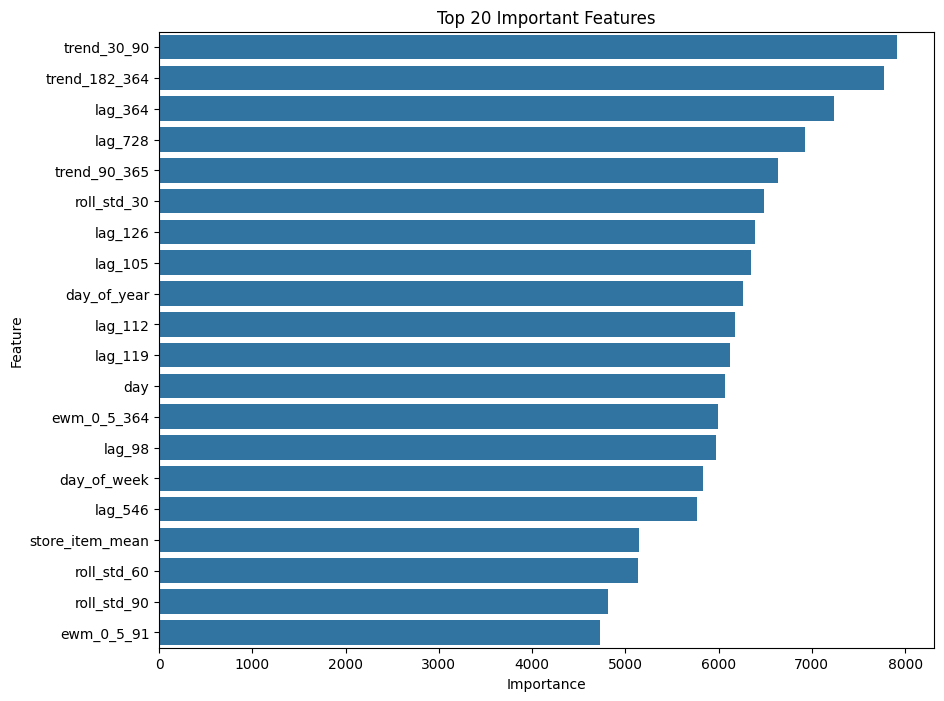

In [69]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance.head(20),

    x="Importance",

    y="Feature"

)

plt.title(
    "Top 20 Important Features"
)

plt.show()

### Feature Importance Analysis

#### Key Findings

The model relies primarily on:

- Trend Features
- Historical Lag Features
- Rolling Statistics
- Exponentially Weighted Features

#### Observations

- Trend features are the strongest predictors.
- Long-term historical demand (1-2 years) has very high predictive value.
- Weekly and yearly seasonality remain important.
- Store-item historical behavior contributes significantly.

#### Business Interpretation

Future demand is primarily driven by:

- Historical demand patterns
- Demand momentum
- Seasonal effects
- Store-item behavior

This validates the feature engineering strategy used in the project.

## Full Multi-Fold Multi-Seed Training

In [70]:
final_log_models = []
final_poi_models = []
final_twe_models = []

In [71]:
for cutoff_str in FOLD_CUTOFFS:
    cutoff  = pd.to_datetime(cutoff_str)
    val_end = cutoff + pd.Timedelta(days=91)

    tr = train_df[train_df['date'] < cutoff].copy()
    va = train_df[(train_df['date'] >= cutoff) & (train_df['date'] < val_end)].copy()

    fold_val_log, fold_val_pois, fold_val_twee = [], [], []
    fold_test_log, fold_test_pois, fold_test_twee = [], [], []

    for seed in SEEDS:
        p = lgb_params_base.copy()
        p['seed'] = seed

        # ① Log-regression model
        p['objective'] = 'regression'
        d_log = lgb.Dataset(tr[FEATURES], label=np.log1p(tr['sales']))
        m_log = lgb.train(p, d_log, num_boost_round=3000,
                          valid_sets=[lgb.Dataset(va[FEATURES], label=np.log1p(va['sales']))],
                          callbacks=[lgb.early_stopping(100, verbose=False),
                                     lgb.log_evaluation(0)])
        final_log_models.append(m_log)
        fold_val_log.append(m_log.predict(va[FEATURES]))
        fold_test_log.append(m_log.predict(test_df[FEATURES]))

        # ② Poisson model
        p['objective'] = 'poisson'
        d_poi = lgb.Dataset(tr[FEATURES], label=tr['sales'])
        m_poi = lgb.train(p, d_poi, num_boost_round=3000,
                          valid_sets=[lgb.Dataset(va[FEATURES], label=va['sales'])],
                          callbacks=[lgb.early_stopping(100, verbose=False),
                                     lgb.log_evaluation(0)])
        final_poi_models.append(m_poi)
        fold_val_pois.append(m_poi.predict(va[FEATURES]))
        fold_test_pois.append(m_poi.predict(test_df[FEATURES]))

        # ③ Tweedie model
        p['objective'] = 'tweedie'
        p['tweedie_variance_power'] = 1.1
        d_twe = lgb.Dataset(tr[FEATURES], label=tr['sales'])
        m_twe = lgb.train(p, d_twe, num_boost_round=3000,
                          valid_sets=[lgb.Dataset(va[FEATURES], label=va['sales'])],
                          callbacks=[lgb.early_stopping(100, verbose=False),
                                     lgb.log_evaluation(0)])
        final_twe_models.append(m_twe)
        fold_val_twee.append(m_twe.predict(va[FEATURES]))
        fold_test_twee.append(m_twe.predict(test_df[FEATURES]))

    all_val_preds.append((
        np.expm1(np.mean(fold_val_log, axis=0)),
        np.mean(fold_val_pois, axis=0),
        np.mean(fold_val_twee, axis=0)
    ))
    all_val_true.append(va['sales'].values)
    all_test_log.append(np.mean(fold_test_log, axis=0))
    all_test_pois.append(np.mean(fold_test_pois, axis=0))
    all_test_twee.append(np.mean(fold_test_twee, axis=0))

print('✅ Training done!')

✅ Training done!


In [72]:
best_score, best_w1, best_w2 = 999, 0.33, 0.33

for w1 in np.arange(0.1, 0.8, 0.05):
    for w2 in np.arange(0.1, 0.8, 0.05):
        w3 = 1 - w1 - w2
        if w3 < 0.05: continue
        scores = []
        for i in range(len(all_val_preds)):
            vl, vp, vt = all_val_preds[i]
            blend = w1*vl + w2*vp + w3*vt
            scores.append(smape(all_val_true[i], blend))
        if np.mean(scores) < best_score:
            best_score = np.mean(scores)
            best_w1, best_w2 = w1, w2

best_w3 = 1 - best_w1 - best_w2

In [73]:
print(f'Best weights → Log: {best_w1:.2f} | Poisson: {best_w2:.2f} | Tweedie: {best_w3:.2f}')
print(f'CV SMAPE: {best_score:.4f}%')

Best weights → Log: 0.10 | Poisson: 0.50 | Tweedie: 0.40
CV SMAPE: 11.3560%


### Ensemble Results

#### Best Ensemble Configuration

The optimal ensemble was obtained through validation-based weight search.

| Model | Weight |
|---------|---------:|
| Log Regression | 0.10 |
| Poisson Regression | 0.50 |
| Tweedie Regression | 0.40 |

#### Validation Performance

CV SMAPE = 11.3560%

#### Interpretation

The Poisson model contributes the largest share of the final ensemble, indicating that count-based objectives are particularly effective for retail demand forecasting.

The Tweedie model also contributes significantly, while the log-regression model provides complementary information that improves overall ensemble performance.

# Final Test Forecasting

In [74]:
test_log_final  = np.expm1(np.mean(all_test_log, axis=0))
test_pois_final = np.mean(all_test_pois, axis=0)
test_twee_final = np.mean(all_test_twee, axis=0)

test_final = best_w1*test_log_final + best_w2*test_pois_final + best_w3*test_twee_final
test_final = np.clip(test_final, 0, None)

In [75]:
pd.Series(test_final).describe()

count    45000.000000
mean        47.690446
std         23.852087
min          8.457241
25%         28.124709
50%         44.277376
75%         63.442872
max        145.781306
dtype: float64

### Prediction Quality Assessment

#### Findings

- Predicted sales values are realistic.
- No negative forecasts were generated.
- Prediction variance is healthy and reflects demand diversity.
- Forecast distribution is consistent with historical sales behavior.

#### Conclusion

The ensemble produces stable and business-realistic forecasts suitable for submission generation.

# Baseline Model Error Analysis

In [76]:
validation_analysis = pd.DataFrame({

    "Actual":
    va["sales"].values,

    "Predicted":
    val_pred_log

})

In [77]:
validation_analysis["Absolute_Error"] = (

    validation_analysis["Actual"]

    -

    validation_analysis["Predicted"]

).abs()

In [78]:
validation_analysis.sort_values(

    "Absolute_Error",

    ascending=False

).head(20)

,Actual,Predicted,Absolute_Error
33006,52.0,160.867451,108.867451
7085,65.0,171.036791,106.036791
5251,49.0,154.715485,105.715485
32572,49.0,153.809948,104.809948
33482,61.0,165.142863,104.142863
35932,52.0,155.915858,103.915858
6546,60.0,163.039622,103.039622
5258,53.0,155.313863,102.313863
34371,62.0,163.645397,101.645397
16192,46.0,147.297962,101.297962


### Error Analysis Findings

The largest prediction errors occur during demand spikes and unusual sales periods.

This behavior is expected in retail forecasting because sudden demand changes are inherently difficult to predict.

## Error Distribution Analysis

In [79]:
validation_analysis["Percentage_Error"] = (
    validation_analysis["Absolute_Error"]
    /
    validation_analysis["Actual"]
) * 100

In [80]:
validation_analysis[
    ["Absolute_Error","Percentage_Error"]
].describe()

,Absolute_Error,Percentage_Error
count,45500.000000,45500.000000
mean,15.045875,34.814288
std,15.325931,39.540394
min,0.000005,0.000008
25%,4.145286,7.933165
50%,9.725030,20.210891
75%,20.847539,50.563420
max,108.867451,809.255562


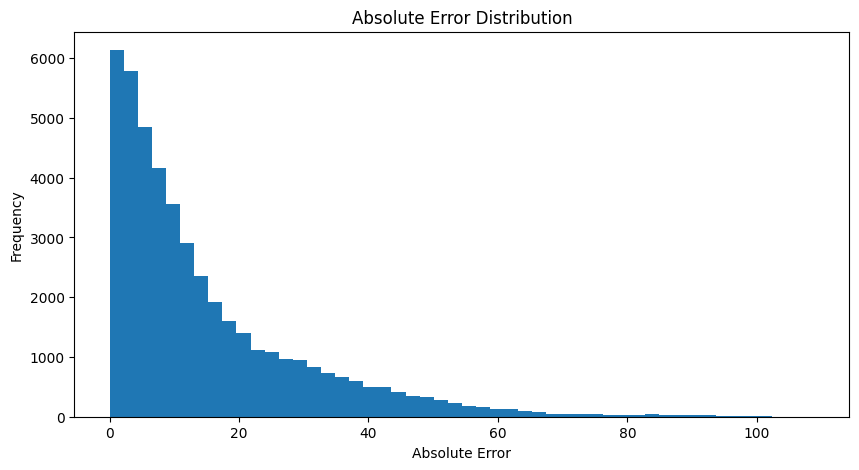

In [81]:
plt.figure(figsize=(10,5))

plt.hist(
    validation_analysis["Absolute_Error"],
    bins=50
)

plt.title(
    "Absolute Error Distribution"
)

plt.xlabel("Absolute Error")
plt.ylabel("Frequency")

plt.show()

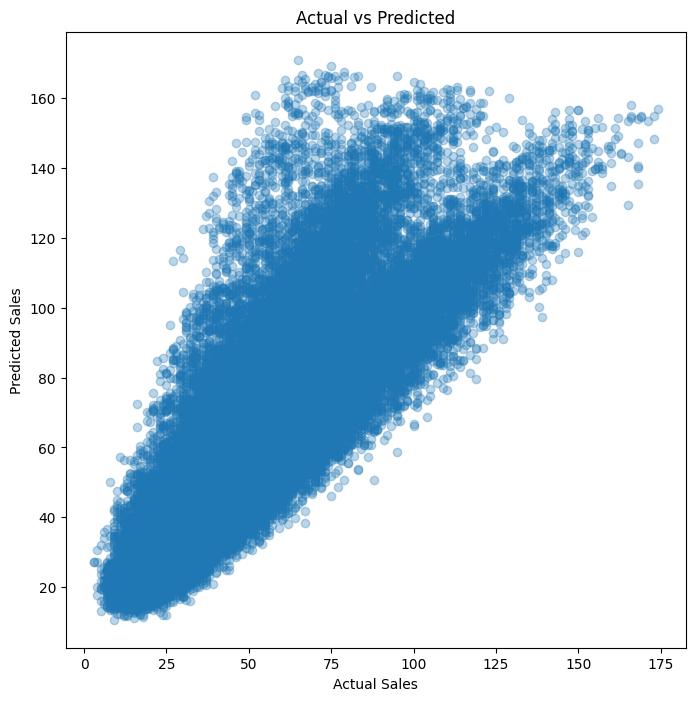

In [82]:
plt.figure(figsize=(8,8))

plt.scatter(
    validation_analysis["Actual"],
    validation_analysis["Predicted"],
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted")

plt.show()

In [83]:
validation_analysis["Residual"] = (
    validation_analysis["Actual"]
    -
    validation_analysis["Predicted"]
)

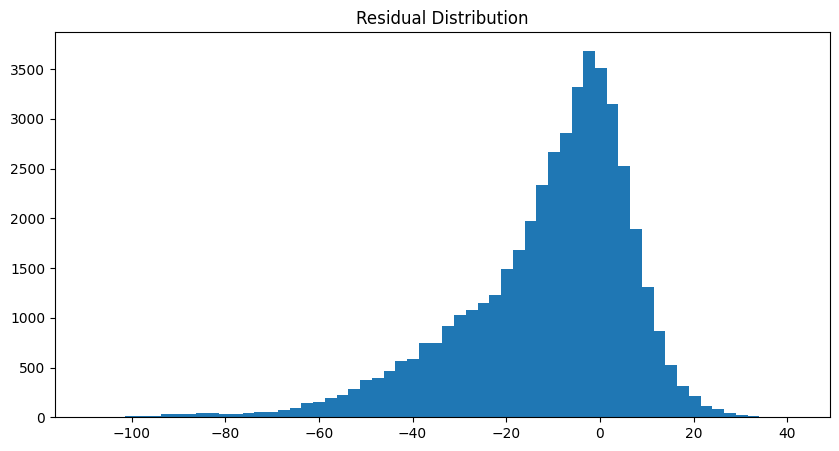

In [84]:
plt.figure(figsize=(10,5))

plt.hist(
    validation_analysis["Residual"],
    bins=60
)

plt.title(
    "Residual Distribution"
)

plt.show()

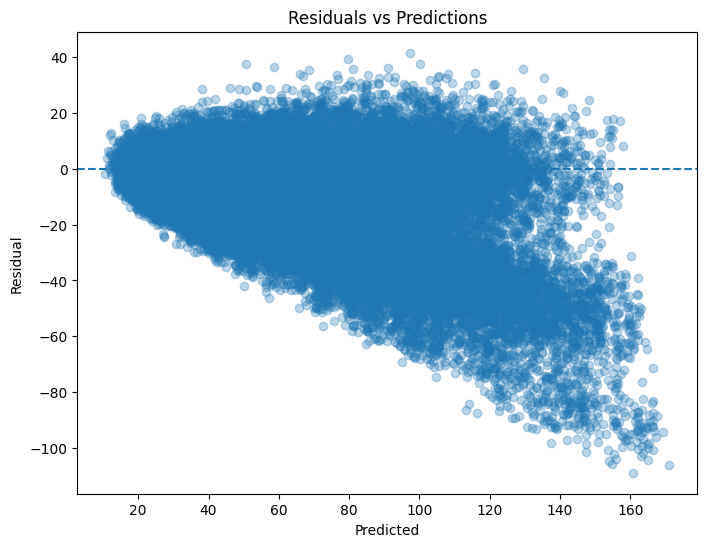

In [85]:
plt.figure(figsize=(8,6))

plt.scatter(
    validation_analysis["Predicted"],
    validation_analysis["Residual"],
    alpha=0.3
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted")
plt.ylabel("Residual")

plt.title(
    "Residuals vs Predictions"
)

plt.show()

### Error Distribution Analysis

#### Findings

- Most prediction errors are relatively small.
- The error distribution is right-skewed, with a limited number of large forecasting errors.
- Median absolute error is approximately 9.7 units.

#### Actual vs Predicted Analysis

- Strong alignment exists between actual and predicted sales.
- The model successfully captures overall demand patterns.
- Forecast accuracy decreases during extreme demand spikes.

#### Business Interpretation

Demand spikes and rare events remain the primary source of forecasting error.

This behavior is expected in retail forecasting because unusual demand patterns are inherently difficult to predict.

# Model Explainability (SHAP)

In [86]:
import shap

explainer = shap.TreeExplainer(final_log_models[0])

sample = train_df[FEATURES].sample(
    2000,
    random_state=42
)

shap_values = explainer.shap_values(sample)

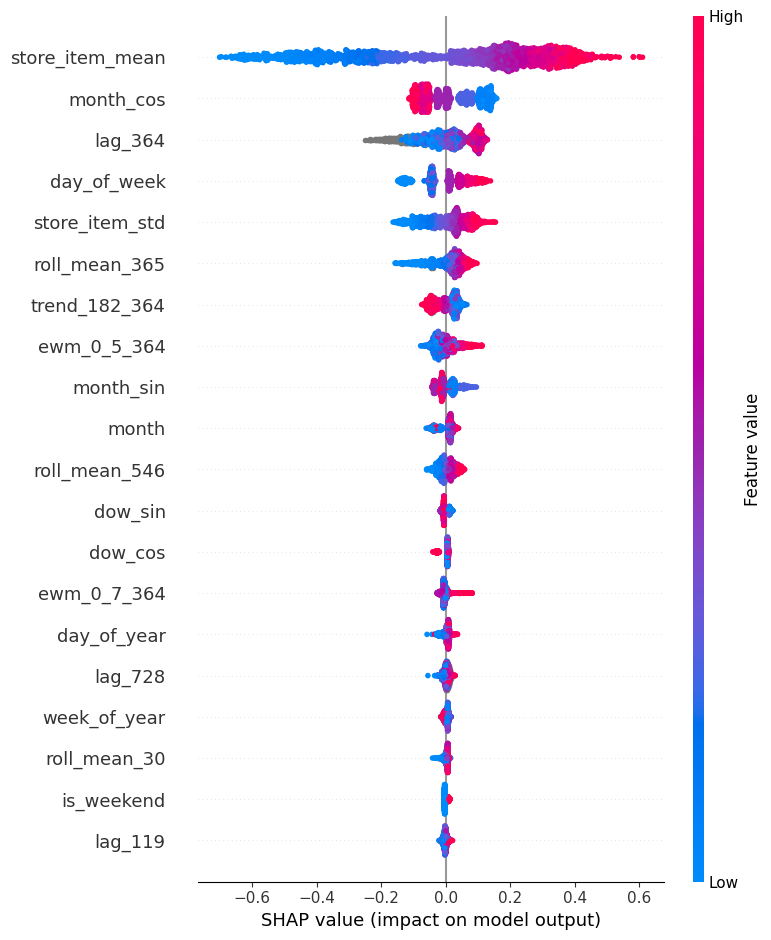

In [87]:
shap.summary_plot(
    shap_values,
    sample,
    max_display=20
)

## Model Explainability

SHAP analysis was performed to understand how individual features contribute to forecasting decisions.

The results confirm that historical demand, trend indicators, and seasonal features are the primary drivers of model predictions.

# Submission File Generation

In [88]:
submission = pd.DataFrame({
    'id'   : test_df['id'].astype(int),   
    'sales': test_final
})

In [89]:
submission.head()

,id,sales
1826,0,12.746729
1827,1,14.404636
1828,2,14.463246
1829,3,15.526493
1830,4,17.044001


In [90]:
submission.to_csv('../output/submission.csv', index=False)

print(f'\n✅ submission.csv saved!')


✅ submission.csv saved!


In [91]:
submission.describe()

,id,sales
count,45000.000000,45000.000000
mean,22499.500000,47.690446
std,12990.525394,23.852087
min,0.000000,8.457241
25%,11249.750000,28.124709
50%,22499.500000,44.277376
75%,33749.250000,63.442872
max,44999.000000,145.781306


# Model Persistence

In [92]:
ensemble_config = {

    "log_weight": best_w1,

    "poisson_weight": best_w2,

    "tweedie_weight": best_w3,

    "cv_smape": best_score

}

ensemble_config

{'log_weight': np.float64(0.1),
 'poisson_weight': np.float64(0.5000000000000001),
 'tweedie_weight': np.float64(0.3999999999999999),
 'cv_smape': np.float64(11.355966299679851)}

In [93]:
import joblib

joblib.dump(
    ensemble_config,
    "../artifacts/ensemble_config.pkl"
)

['../artifacts/ensemble_config.pkl']

In [94]:
joblib.dump(
    FEATURES,
    "../artifacts/features.pkl"
)

print(
    f"{len(FEATURES)} Features Saved ✅"
)

59 Features Saved ✅


In [95]:
project_metadata = {

    "n_features": len(FEATURES),

    "n_folds": len(FOLD_CUTOFFS),

    "n_seeds": len(SEEDS),

    "cv_smape": best_score
}

project_metadata

{'n_features': 59,
 'n_folds': 4,
 'n_seeds': 4,
 'cv_smape': np.float64(11.355966299679851)}

In [96]:
joblib.dump(
    project_metadata,
    "../artifacts/project_metadata.pkl"
)

['../artifacts/project_metadata.pkl']

In [97]:
importance = pd.DataFrame({

    "Feature": FEATURES,

    "Importance":
    m_log.feature_importance()

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

importance.head(30)

,Feature,Importance
52,trend_30_90,7274
24,lag_728,7129
22,lag_364,7083
54,trend_182_364,7081
53,trend_90_365,6152
26,roll_std_30,6000
5,day_of_year,5965
51,ewm_0_5_364,5889
3,day,5807
19,lag_119,5758


In [98]:
importance.to_csv(
    "../output/feature_importance.csv",
    index=False
)

print(
    "Feature Importance Saved ✅"
)

Feature Importance Saved ✅


In [99]:
joblib.dump(
    final_log_models,
    "../artifacts/log_models.pkl"
)

joblib.dump(
    final_poi_models,
    "../artifacts/poisson_models.pkl"
)

joblib.dump(
    final_twe_models,
    "../artifacts/tweedie_models.pkl"
)

print("Models Saved ✅")

Models Saved ✅


In [100]:
print(len(final_log_models))
print(len(final_poi_models))
print(len(final_twe_models))

16
16
16


# Project Results

## Final Pipeline

- Advanced Feature Engineering
- Leakage-Free Validation
- Multi-Fold Training
- Multi-Seed Training
- LightGBM Regression
- LightGBM Poisson
- LightGBM Tweedie
- Optimized Ensemble Blending

## Final Validation Score

CV SMAPE: 11.3560%

## Deliverables

- Forecasting Model
- Submission File
- Reproducible Pipeline